<a href="https://colab.research.google.com/github/Mark-at/comp551-AppliedMachineLearning/blob/main/551a3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# McGill COMP551, MINI-PROJECT 3: Odd-One-Out Image Groups
Student names (IDs) - **Kaggle team name**


# Kaggle Competition
Training and test data are available as part of the assignment in the `datasets` folder. To participate in the competition you should upload a CSV file containing your predicted labels for the entire test data to Kaggle.

The test data is divided in half. You receive the correct labels for the first half (in the `datasets` folder), so that you can evaluate your model in this notebook on that part of the test set. You then submit your solution for the entire test set to Kaggle. The final evaluation is based on your predictions for the second half of the test set (private leaderboard). We have step-by-step explanation in the final section of this notebook.


# Report
The purpose of this notebook is for you to provide a concise high level code of your methodology. That is, you need to include all steps necessary to reproduce your results. Please include a high-level explanation of the implementation so that we can understand what you're trying to achieve in each piece of the code. You can import python code here if needed, in order to keep the notebook concise.

**Note:** You need to submit this notebook where you have run all the cells as part of the assignment. **We should not need to rerun your code since this can take a long time.**


## Step 1 — The Dataset
Use the following code to load the data using the npy files. We have **3,000 training examples**, where each example is a group of **5 grayscale images** (each 32×32). In each group:
- **4 images** share a hidden common property, and
- **1 image** is the **outlier**.

You do **not** have access to the underlying attributes. Your task is to learn to identify the **index** of the outlier image (a 5-class classification problem, with labels in {0, 1, 2, 3, 4}). The label is printed above each group shown below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader # Replaced TensorDataset with Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import copy

x = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/x_train.npy')  # (3000, 5, 32, 32) — 3000 groups of 5 images each
y = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/y_train.npy') # (3000,) — index of the outlier image in each group (0-4)

print(f'Training set: {x.shape[0]} groups, each with {x.shape[1]} images of size {x.shape[2]}x{x.shape[3]}')
print(f'Labels: values in {np.unique(y)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training set: 3000 groups, each with 5 images of size 32x32
Labels: values in [0 1 2 3 4]


In [ ]:
def plot_groups(x, y, num_groups=5):
    """Plot groups of 5 images. The outlier is highlighted with a red border."""
    fig, axes = plt.subplots(num_groups, 5, figsize=(10, 2 * num_groups))
    for i in range(num_groups):
        for j in range(5):
            axes[i, j].imshow(x[i, j], cmap='gray')
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            if j == y[i]:
                for spine in axes[i, j].spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                axes[i, j].set_title('outlier', color='red', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_groups(x, y, num_groups=5)

## Step 2 — Example: Logistic Regression Baseline
Below we apply a simple logistic regression to the flattened input as a demonstration. This model treats the entire group of 5 images as one flat vector and does not use any deep learning.

Note that **random chance** for this 5-class problem is **20%** (1/5).
As you can see, the logistic regression baseline performs close to random chance — you are expected to do significantly better using a deep learning model implemented in PyTorch (or Jax/TensorFlow).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader # Replaced TensorDataset with Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import copy

features = x.reshape(x.shape[0], -1)  # flatten each group of 5 images into a single vector
labels = y

x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.33, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)

predictions = clf.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print(f'The validation accuracy of the baseline model is {accuracy * 100:.2f}%')

The validation accuracy of the baseline model is 19.39%


## Step 3 — Your Model
This is the main part of your report. Provide your model implementation, training code, and explanation below. Details should include the architecture, choice of hyperparameters, and any preprocessing or augmentation you applied. If you performed a hyperparameter search, explain it here.

**Important:** Your model must have at most **25,000** trainable parameters. You **must** uncomment and run the cell below to print and verify the parameter count. This count must also appear in your report.

In [ ]:
import copy
import random
import itertools

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import numpy as np
import matplotlib.pyplot as plt
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class OutlierDataset(Dataset):
    def __init__(self, features, labels, augment=False):
        self.features = features
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        group = self.features[idx].clone()
        label = self.labels[idx].item()
        H, W = group.shape[2], group.shape[3]

        if self.augment:
            angle = random.uniform(-10, 10)
            tx = random.randint(-3, 3)
            ty = random.randint(-3, 3)
            scale = random.uniform(0.92, 1.08)
            do_hflip = random.random() > 0.5
            do_vflip = random.random() > 0.5

            augmented = []
            for img in group:
                if do_hflip:
                    img = TF.hflip(img)
                if do_vflip:
                    img = TF.vflip(img)

                img = TF.affine(
                    img, angle=angle, translate=[tx, ty],
                    scale=scale, shear=[0.0, 0.0],
                    interpolation=InterpolationMode.BILINEAR, fill=0
                )

                # Light instance-wise noise
                img = img + torch.randn_like(img) * 0.01

                # Smaller, less frequent cutout
                if random.random() > 0.5:
                    ps = random.randint(3, max(4, H // 6))
                    i_pos = random.randint(0, H - ps)
                    j_pos = random.randint(0, W - ps)
                    img[:, i_pos:i_pos+ps, j_pos:j_pos+ps] = 0

                img = torch.clamp(img, 0.0, 1.0)
                augmented.append(img)

            group = torch.stack(augmented)

            # Recompute deviation channel after augmentation
            raw = group[:, 0, :, :]
            for i in range(5):
                mask = [j for j in range(5) if j != i]
                others_med = raw[mask].median(dim=0)[0]
                group[i, 1] = torch.abs(raw[i] - others_med)
            dev_max = group[:, 1].reshape(5, -1).max(dim=1)[0].view(5, 1, 1)
            group[:, 1] = group[:, 1] / (dev_max + 1e-8)

            # Position shuffling
            indices = list(range(5))
            random.shuffle(indices)
            group = group[indices]
            label = indices.index(label)

        return group, torch.tensor(label, dtype=torch.long)
class ImprovedOutlierDetector(nn.Module):
    def __init__(self, c1=16, c2=32, c3=36, pair_h=40, score_h=20):
        super().__init__()
        self.c3 = c3
        self.score_h = score_h

        # CNN backbone — input is now 3-channel (original + deviation + edges)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=3, padding=1),   # <-- 3 input channels
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Pair MLP: [fi, diff, |diff|] = 3 * c3
        self.pair_mlp = nn.Sequential(
            nn.Linear(3 * c3, pair_h),
            nn.ReLU(inplace=True),
            nn.Linear(pair_h, score_h),
            nn.ReLU(inplace=True)
        )

        self.attn_layer = nn.Linear(score_h, 1)

        # Scorer: score_h + 3 global stats
        self.scorer = nn.Sequential(
            nn.Linear(score_h + 3, score_h // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(score_h // 2, 1)
        )

    def forward(self, x):
        B, N, C, H, W = x.size()   # N=5, C=3

        # Extract features — CNN already gets 3-channel input with
        # deviation + edge info baked in
        x_flat = x.view(B * N, C, H, W)
        features = self.cnn(x_flat).view(B, N, self.c3)

        # Feature-space leave-one-out stats
        feat_sum = features.sum(dim=1, keepdim=True)
        feat_loo_mean = (feat_sum - features) / (N - 1.0)

        cos_sim = F.cosine_similarity(features, feat_loo_mean, dim=-1).unsqueeze(-1)
        l2_dist = torch.norm(features - feat_loo_mean, dim=-1, keepdim=True)

        # Variance contribution
        group_var = features.var(dim=1, keepdim=True).sum(dim=-1, keepdim=True)
        var_contribs = []
        for i in range(N):
            mask = [j for j in range(N) if j != i]
            others_var = features[:, mask, :].var(dim=1).sum(dim=-1, keepdim=True)
            var_contribs.append(others_var)
        var_without = torch.stack(var_contribs, dim=1)
        var_contrib = group_var.expand_as(var_without) - var_without

        # Pairwise comparisons
        scores = []
        for i in range(N):
            fi = features[:, i, :]
            pair_reprs = []
            for j in range(N):
                if j == i:
                    continue
                fj = features[:, j, :]
                diff = fi - fj
                abs_diff = torch.abs(diff)
                pair_input = torch.cat([fi, diff, abs_diff], dim=1)
                pair_reprs.append(self.pair_mlp(pair_input))

            pair_reprs = torch.stack(pair_reprs, dim=1)
            attn_logits = self.attn_layer(pair_reprs)
            attn_weights = F.softmax(attn_logits, dim=1)
            agg_repr = (attn_weights * pair_reprs).sum(dim=1)

            scorer_input = torch.cat([
                agg_repr,
                cos_sim[:, i, :],
                l2_dist[:, i, :],
                var_contrib[:, i, :]
            ], dim=1)

            scores.append(self.scorer(scorer_input).squeeze(-1))

        return torch.stack(scores, dim=1)
_test_model = ImprovedOutlierDetector()
total_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'
del _test_model

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_model(x_train, y_train, x_val=None, y_val=None,
                num_epochs=200, batch_size=64, lr=1e-3,
                weight_decay=1e-4, seed=42, verbose=True):
    """
    Train a single model.
    If x_val/y_val are None, trains without validation (for final submission).
    Returns: (best_model_state_dict, training_history_dict)
    """
    set_seed(seed)

    train_dataset = OutlierDataset(x_train, y_train, augment=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, drop_last=False)

    has_val = x_val is not None and y_val is not None
    if has_val:
        val_dataset = OutlierDataset(x_val, y_val, augment=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = ImprovedOutlierDetector().to(DEVICE)

    if verbose:
        tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Trainable parameters: {tp:,}')

    criterion = nn.CrossEntropyLoss(label_smoothing=0.01)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Cosine annealing with warm restarts — cycles at T=30, then 60, then 120
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-5
    )

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        scheduler.step()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # --- Validation ---
        if has_val:
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    preds = outputs.argmax(dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            epoch_val_loss = val_loss / val_total
            epoch_val_acc = val_correct / val_total
            history['val_loss'].append(epoch_val_loss)
            history['val_acc'].append(epoch_val_acc)

            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                best_epoch = epoch + 1

            if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
                print(f'Epoch {epoch+1:03d}/{num_epochs} | '
                      f'Train: {epoch_train_acc*100:.1f}% | '
                      f'Val: {epoch_val_acc*100:.1f}% (best: {best_val_acc*100:.1f}% @ ep{best_epoch})')
        else:
            # No validation — always save latest weights
            best_model_wts = copy.deepcopy(model.state_dict())
            if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
                print(f'Epoch {epoch+1:03d}/{num_epochs} | '
                      f'Train: {epoch_train_acc*100:.1f}% | Loss: {epoch_train_loss:.4f}')

    if has_val and verbose:
        print(f'\nBest Validation Accuracy: {best_val_acc*100:.2f}% at epoch {best_epoch}')

    return best_model_wts, history

Total trainable parameters: 21,112


In [ ]:
import torch
import torch.nn.functional as F_func
import numpy as np

def compute_edge_map(images):
    """
    Compute gradient magnitude (Sobel-like) for each image.
    images: (N, 5, H, W) tensor
    returns: (N, 5, H, W) tensor of edge magnitudes
    """
    # Sobel kernels
    sobel_x = torch.tensor([[-1, 0, 1],
                             [-2, 0, 2],
                             [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1],
                             [ 0,  0,  0],
                             [ 1,  2,  1]], dtype=torch.float32).view(1, 1, 3, 3)

    N, G, H, W = images.shape
    flat = images.view(N * G, 1, H, W)

    gx = F_func.conv2d(flat, sobel_x, padding=1)
    gy = F_func.conv2d(flat, sobel_y, padding=1)
    magnitude = torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)

    # Normalize to [0, 1] per image
    mag_flat = magnitude.view(N * G, -1)
    mag_min = mag_flat.min(dim=1, keepdim=True)[0].view(N * G, 1, 1, 1)
    mag_max = mag_flat.max(dim=1, keepdim=True)[0].view(N * G, 1, 1, 1)
    magnitude = (magnitude - mag_min) / (mag_max - mag_min + 1e-8)

    return magnitude.view(N, G, H, W)


def compute_deviation_maps(images):
    """
    For each image i, compute |image_i - median_of_other_4| at pixel level.
    Uses median instead of mean for robustness to the outlier.
    images: (N, 5, H, W) tensor
    returns: (N, 5, H, W) tensor
    """
    N, G, H, W = images.shape
    dev_maps = torch.zeros_like(images)

    for i in range(G):
        # Get the other 4 images
        mask = [j for j in range(G) if j != i]
        others = images[:, mask, :, :]            # (N, 4, H, W)
        others_median = others.median(dim=1)[0]   # (N, H, W)
        dev_maps[:, i] = torch.abs(images[:, i] - others_median)

    # Normalize per-image to [0, 1]
    flat = dev_maps.view(N * G, -1)
    fmax = flat.max(dim=1, keepdim=True)[0].view(N * G, 1, 1)
    dev_maps_flat = dev_maps.view(N * G, H, W)
    dev_maps_flat = dev_maps_flat / (fmax + 1e-8)
    return dev_maps_flat.view(N, G, H, W)


def preprocess_groups(images_tensor):
    """
    Convert (N, 5, H, W) single-channel groups into (N, 5, 3, H, W) multi-channel.
    Channel 0: original image
    Channel 1: pixel deviation from median of others
    Channel 2: edge map (Sobel gradient magnitude)
    """
    edges = compute_edge_map(images_tensor)
    deviations = compute_deviation_maps(images_tensor)

    # Stack: (N, 5, 3, H, W)
    return torch.stack([images_tensor, deviations, edges], dim=2)

x_tensor = torch.tensor(x, dtype=torch.float32) / 255.0
y_tensor = torch.tensor(y, dtype=torch.long)

x_processed = preprocess_groups(x_tensor)

x_train, x_val, y_train, y_val = train_test_split(#x_tensor
    x_processed, y_tensor, test_size=0.1, random_state=42, stratify=y_tensor
)

print(f'Train: {len(x_train)}, Val: {len(x_val)}')

# Train one model to see how it does
best_wts, history = train_model(
    x_train, y_train, x_val, y_val,
    num_epochs=250, batch_size=64, lr=2e-3,
    weight_decay=2e-5, seed=233, verbose=True
)

Train: 2700, Val: 300
Trainable parameters: 21,112
Epoch 001/250 | Train: 27.3% | Val: 29.3% (best: 29.3% @ ep1)
Epoch 010/250 | Train: 44.3% | Val: 41.7% (best: 41.7% @ ep10)
Epoch 020/250 | Train: 57.0% | Val: 53.0% (best: 54.7% @ ep16)
Epoch 030/250 | Train: 68.0% | Val: 66.3% (best: 68.0% @ ep29)
Epoch 040/250 | Train: 77.1% | Val: 76.0% (best: 79.0% @ ep39)
Epoch 050/250 | Train: 81.2% | Val: 79.3% (best: 80.3% @ ep45)
Epoch 060/250 | Train: 82.1% | Val: 82.0% (best: 82.0% @ ep56)
Epoch 070/250 | Train: 80.2% | Val: 80.0% (best: 82.3% @ ep67)
Epoch 080/250 | Train: 83.5% | Val: 83.0% (best: 83.3% @ ep79)
Epoch 090/250 | Train: 84.4% | Val: 83.7% (best: 84.0% @ ep81)
Epoch 100/250 | Train: 85.9% | Val: 82.3% (best: 84.3% @ ep92)
Epoch 110/250 | Train: 87.2% | Val: 85.0% (best: 85.3% @ ep107)
Epoch 120/250 | Train: 87.1% | Val: 84.0% (best: 85.3% @ ep107)
Epoch 130/250 | Train: 87.3% | Val: 84.0% (best: 85.3% @ ep107)
Epoch 140/250 | Train: 87.2% | Val: 84.0% (best: 85.3% @ ep107)
E

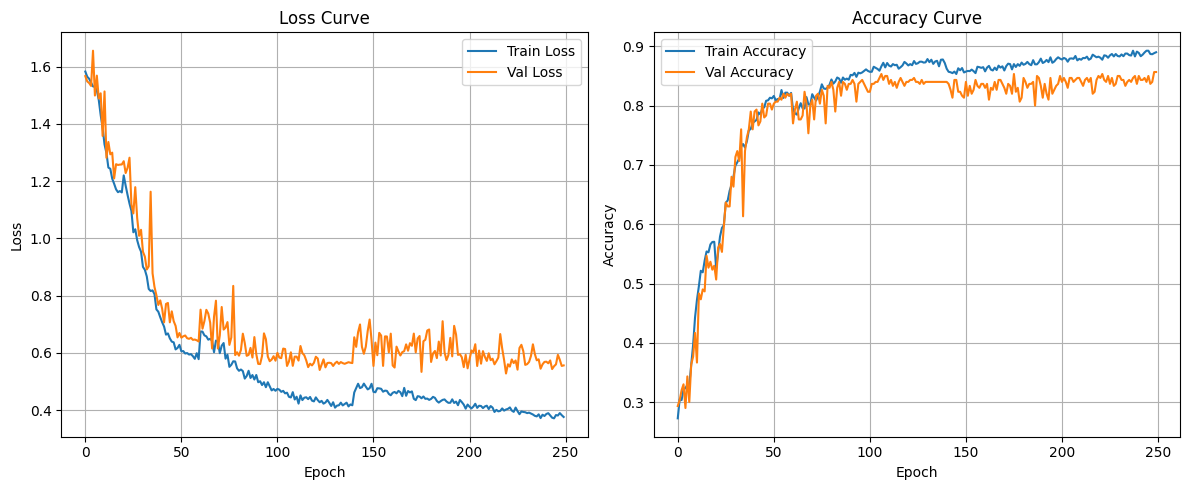

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
if history['val_loss']:
    plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
if history['val_acc']:
    plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

def predict_simple(model, x_data, batch_size=64, device=DEVICE):
    """Simple prediction without TTA."""
    model.eval()
    all_preds = []
    with torch.no_grad():
        for start in range(0, len(x_data), batch_size):
            end = min(start + batch_size, len(x_data))
            inputs = x_data[start:end].to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
    return np.array(all_preds)

In [ ]:
x_test = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/x_test.npy')        # (2000, 5, 32, 32)
x_test_half = x_test[:1000]                                                             # (1000, 5, 32, 32)
y_test_half = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/y_test.npy')

x_test_tensor = torch.tensor(x_test, dtype=torch.float32) / 255.0
x_test_half_tensor = torch.tensor(x_test_half, dtype=torch.float32) / 255.0

print("Preprocessing test data...")
x_test_processed = preprocess_groups(x_test_tensor)            # all 2000
x_test_half_processed = preprocess_groups(x_test_half_tensor)  # public 1000

print(f'Test set: {x_test.shape[0]} groups total')
print(f'Public half: {x_test_half.shape[0]} groups')
print(f'Private half: {x_test.shape[0] - x_test_half.shape[0]} groups\n')

model_eval = ImprovedOutlierDetector().to(DEVICE)
model_eval.load_state_dict(best_wts)

preds_simple = predict_simple(model_eval, x_test_half_processed)
acc_simple = accuracy_score(y_test_half, preds_simple)
print(f'Public test accuracy :   {acc_simple*100:.2f}%')

Preprocessing test data...
Test set: 2000 groups total
Public half: 1000 groups
Private half: 1000 groups

Public test accuracy :   70.30%


In [ ]:
# ============================================================
# REQUIRED: Print the number of trainable parameters in your model.
# Replace `model` with the name of your PyTorch model.
# This cell MUST appear with its output in your submitted notebook.
# ============================================================

# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Total trainable parameters: {total_params:,}')
# assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

## Step 4 — Accuracy Metrics and CSV Submission to Kaggle
At minimum, you **must** report in your submitted notebook:
1. The **number of trainable parameters** (printed in Step 3 above).
2. Your accuracy on the **first half of the test set** (public leaderboard).

**This accuracy must match your public leaderboard score on Kaggle.** If it does not, your leaderboard submission is discarded.

Below we show this evaluation for the logistic regression baseline. Note that the baseline accuracy is close to **random chance (20%)** — you should aim to do much better.

In [ ]:
x_test = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/x_test.npy')        # (2000, 5, 32, 32)
x_test_half = x_test[:1000]                                                             # (1000, 5, 32, 32)
y_test_half = np.load('/content/drive/MyDrive/Colab Notebooks/datasets/y_test.npy')    # (1000,) — true labels for the first half only

print(f'Test set: {x_test.shape[0]} groups total')
print(f'Public half: {x_test_half.shape[0]} groups (labels provided)')
print(f'Private half: {x_test.shape[0] - x_test_half.shape[0]} groups (labels hidden)\n')

predictions = clf.predict(x_test_half.reshape(x_test_half.shape[0], -1))
accuracy = accuracy_score(y_test_half, predictions)
print(f'Public test accuracy (should match public leaderboard): {accuracy * 100:.2f}%')

Test set: 2000 groups total
Public half: 1000 groups (labels provided)
Private half: 1000 groups (labels hidden)

Public test accuracy (should match public leaderboard): 20.90%


In [ ]:
# ============================================================
# REQUIRED: Print your model's accuracy on the public test half.
# This number MUST match your public leaderboard score on Kaggle.
# Replace the code below with your own model's predictions.
# ============================================================
model_eval = ImprovedOutlierDetector().to(DEVICE)
model_eval.load_state_dict(best_wts)

full_test_preds = predict_simple(model_eval, x_test_processed)  # x_test_processed is all 2000
print(f'Predictions: {len(full_test_preds)}')  # should print 2000

# Verify on public half
public_acc = accuracy_score(y_test_half, full_test_preds[:1000])
print(f'Public test accuracy: {public_acc*100:.2f}%')


import pandas as pd

def generate_csv_kaggle(y):
    indexes = np.arange(len(y))
    csv_labels = np.concatenate((indexes.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
    df = pd.DataFrame(csv_labels, columns=['Id', 'Category'])
    df['Id'] = df['Id'].astype(str)
    df['Category'] = df['Category'].astype(str)
    df.to_csv('predicted_labels.csv', index=False)

# Baseline prediction for the entire test set (2000 groups)
generate_csv_kaggle(full_test_preds)
print(f'Saved {len(full_test_preds)} predictions to predicted_labels.csv')

Predictions: 2000
Public test accuracy: 70.30%
Saved 2000 predictions to predicted_labels.csv


### Generating the CSV for Kaggle Submission
In order to submit your results to Kaggle you need to provide your predictions in CSV format. The code below shows how to do this for the logistic regression baseline above. You can use the same method for your submission.

Note that you need to submit your result for the **entire test set** of size **2,000**. Your accuracy on the first 1,000 will show on the public leaderboard and the remaining 1,000 are on the private leaderboard that will be revealed when the competition is over. Submit the `predicted_labels.csv` to the Kaggle competition!

In [ ]:
import pandas as pd

def generate_csv_kaggle(y):
    indexes = np.arange(len(y))
    csv_labels = np.concatenate((indexes.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
    df = pd.DataFrame(csv_labels, columns=['Id', 'Category'])
    df['Id'] = df['Id'].astype(str)
    df['Category'] = df['Category'].astype(str)
    df.to_csv('predicted_labels.csv', index=False)

# Baseline prediction for the entire test set (2000 groups)
generate_csv_kaggle(full_test_preds)
print(f'Saved {len(full_test_preds)} predictions to predicted_labels.csv')

In [ ]:
from google.colab import files
files.download('predicted_labels.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>